In [1]:
from google.colab import drive
import sys

# Standard mount to access the config file initially
drive.mount('/content/drive')
sys.path.append('/content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench/src')

from utils.config import initialize_project
initialize_project()

Mounted at /content/drive
Authenticated as: Ande404
Working Directory: /content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench


In [2]:
import os
from collections import Counter

data_dir = "data/raw/PlantVillage"

classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
print("Number of classes:", len(classes))
print("Sample classes:", classes[:10])

class_counts = {}
for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    class_counts[cls] = len([
        f for f in os.listdir(cls_path)
        if os.path.isfile(os.path.join(cls_path, f))
    ])

print("Min class size:", min(class_counts.values()))
print("Max class size:", max(class_counts.values()))


Number of classes: 15
Sample classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot']
Min class size: 152
Max class size: 3209


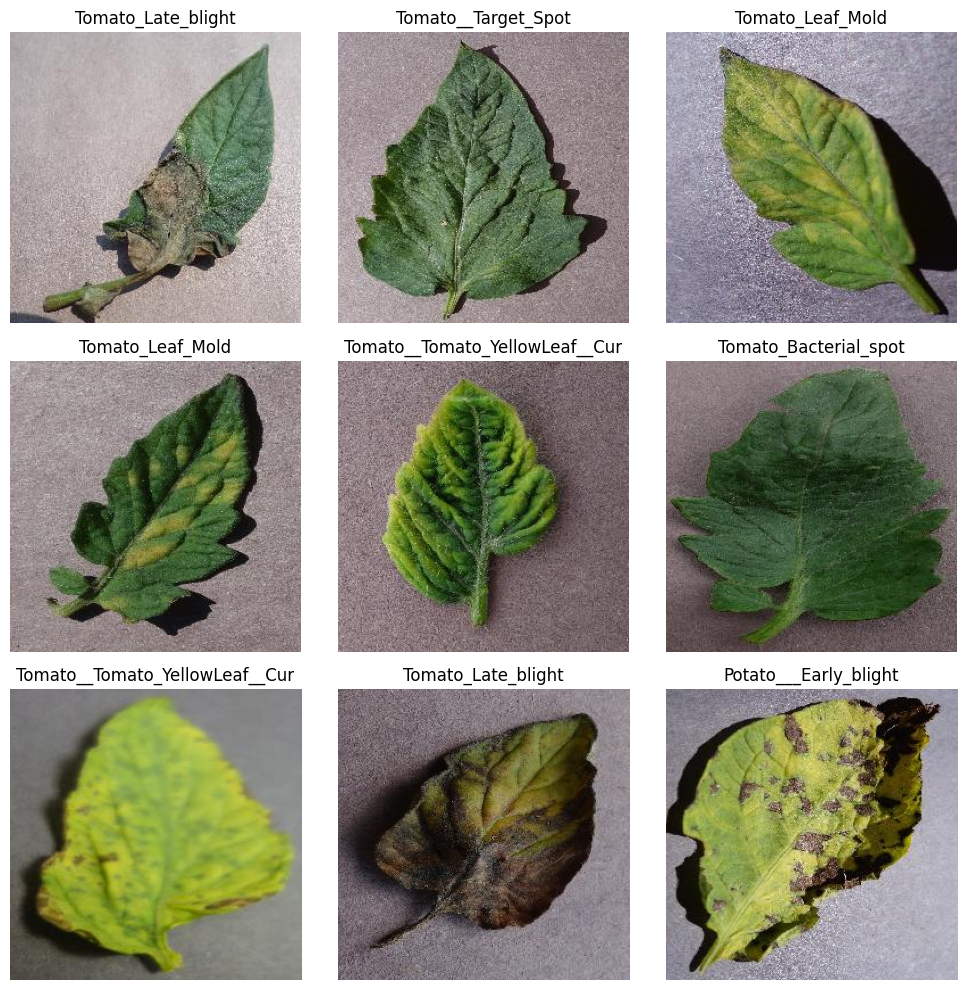

In [3]:
import matplotlib.pyplot as plt
from PIL import Image
import random

fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for ax in axes.flat:
    cls = random.choice(classes)
    cls_path = os.path.join(data_dir, cls)
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)

    img = Image.open(img_path).convert("RGB")
    ax.imshow(img)
    ax.set_title(cls[:30])
    ax.axis("off")

plt.tight_layout()
plt.show()